<a href="https://colab.research.google.com/github/ruthAlt/Occupancy-Detection-ML/blob/main/notebooks/MLproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import itertools

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import (train_test_split, learning_curve, validation_curve, KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SequentialFeatureSelector as SFS

from scipy.stats import loguniform, beta, uniform

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as IMBPipeline

import missingno as msno

import warnings
warnings.filterwarnings('ignore')

# Introduction
The goal of this project is to develop a Machine Learning model capable of predicting whether a room is Occupied(1) or Empty (0) using only environmental sensor data.

In the Heating, Ventilating, and Air Conditioning sector, energy efficiency is a primary concern. Traditional systems ofter rely on manual thermostats or simple timers. However, if a room remains conditioned while empty, significant energy waste occurs. By accurately predicting occupancy using sensors, we can design Smart systems that automatically shut down or reduce power when no occupants are present, drastically reducing carbon footprints and operational costs.


Dataset URL: https://archive.ics.uci.edu/dataset/357/occupancy+detection

I only use one of the dataset named datatraining.txt

In [91]:
df = pd.read_csv('/content/drive/MyDrive/ML_Project/datatraining.txt')

In [92]:
df.head(5)

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
1,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


In [93]:
df.describe()

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000
mean,20.619084,25.731507,119.519375,606.546243,0.003863,0.212330
std,1.016916,5.531211,194.755805,314.320877,0.000852,0.408982
min,19.000000,16.745000,0.000000,412.750000,0.002674,0.000000
25%,19.700000,20.200000,0.000000,439.000000,0.003078,0.000000
50%,20.390000,26.222500,0.000000,453.500000,0.003801,0.000000
75%,21.390000,30.533333,256.375000,638.833333,0.004352,0.000000
max,23.180000,39.117500,1546.333333,2028.500000,0.006476,1.000000


# Dataset Description
The dataset consists of 8,143 observations and has seven columns: date, temperature, humidity, light, CO2, humidity ratio and occupancy.


*   Date (timestamp of the reading)
*   Temperature in Celsius
*   Relative humidity as percentage
*   Light measured in lux
*   CO2 measured in parts per million
*   Humidity ratio derived from temperature and relative humidity measured in kilograms of water vapor per kilogram of air
*   Occupancy (our target) is either 1 for occupied or 0 for not occupied.







In [94]:
df['date'] = pd.to_datetime(df['date'])
df.reset_index(drop=True, inplace=True)

In [95]:
target = 'Occupancy'
X = df.drop(columns=[target])
y = df[target]

In [96]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8143 entries, 0 to 8142
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           8143 non-null   datetime64[ns]
 1   Temperature    8143 non-null   float64       
 2   Humidity       8143 non-null   float64       
 3   Light          8143 non-null   float64       
 4   CO2            8143 non-null   float64       
 5   HumidityRatio  8143 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 381.8 KB


To demonstrate the robustness of the machine learning pipeline, I will intentionally introduce synthetic noise into the feature set before training phase.

`add_missing`
function to inject NaN values into specific columns to simulate a scenario where a specific sensor (e.g. the light or CO2 sensor) fails or provides an empty reading while other continue to function.

`add_missing_rows` function to set entire rows of features to NaN to simulate failure or power outage where all sensor readings for a specific timestamp are lost.



In [97]:
def add_missing(col, amount):
  X = col.copy()
  size = amount if amount >= 1 else int(len(X)* amount)
  indexes = np.random.choice(len(X), size, replace=False)
  X.iloc[indexes] = np.nan
  return X

def add_missing_rows(df, amount):
  X = df.copy()
  rows, cols = X.shape
  size = amount if amount >= 1 else int(rows * amount)
  indexes = np.random.choice(rows, size, replace = False)
  for i in indexes:
    X.loc[i] = np.full((cols,), np.nan)
  return X

In [98]:
X['Light'] = add_missing(X['Light'], 0.10)
X['CO2'] = add_missing(X['CO2'], 0.05)
X['Temperature'] = add_missing(X['Temperature'], 100)

X = add_missing_rows(X, 0.01)

In [99]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8143 entries, 0 to 8142
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           8062 non-null   datetime64[ns]
 1   Temperature    7963 non-null   float64       
 2   Humidity       8062 non-null   float64       
 3   Light          7257 non-null   float64       
 4   CO2            7658 non-null   float64       
 5   HumidityRatio  8062 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 381.8 KB


In [100]:
# For each column, returns the percentage of mising values in it
X.isnull().sum(axis=0) / X.shape[0]


,0
date,0.009947
Temperature,0.022105
Humidity,0.009947
Light,0.108805
CO2,0.059560
HumidityRatio,0.009947


<Axes: >

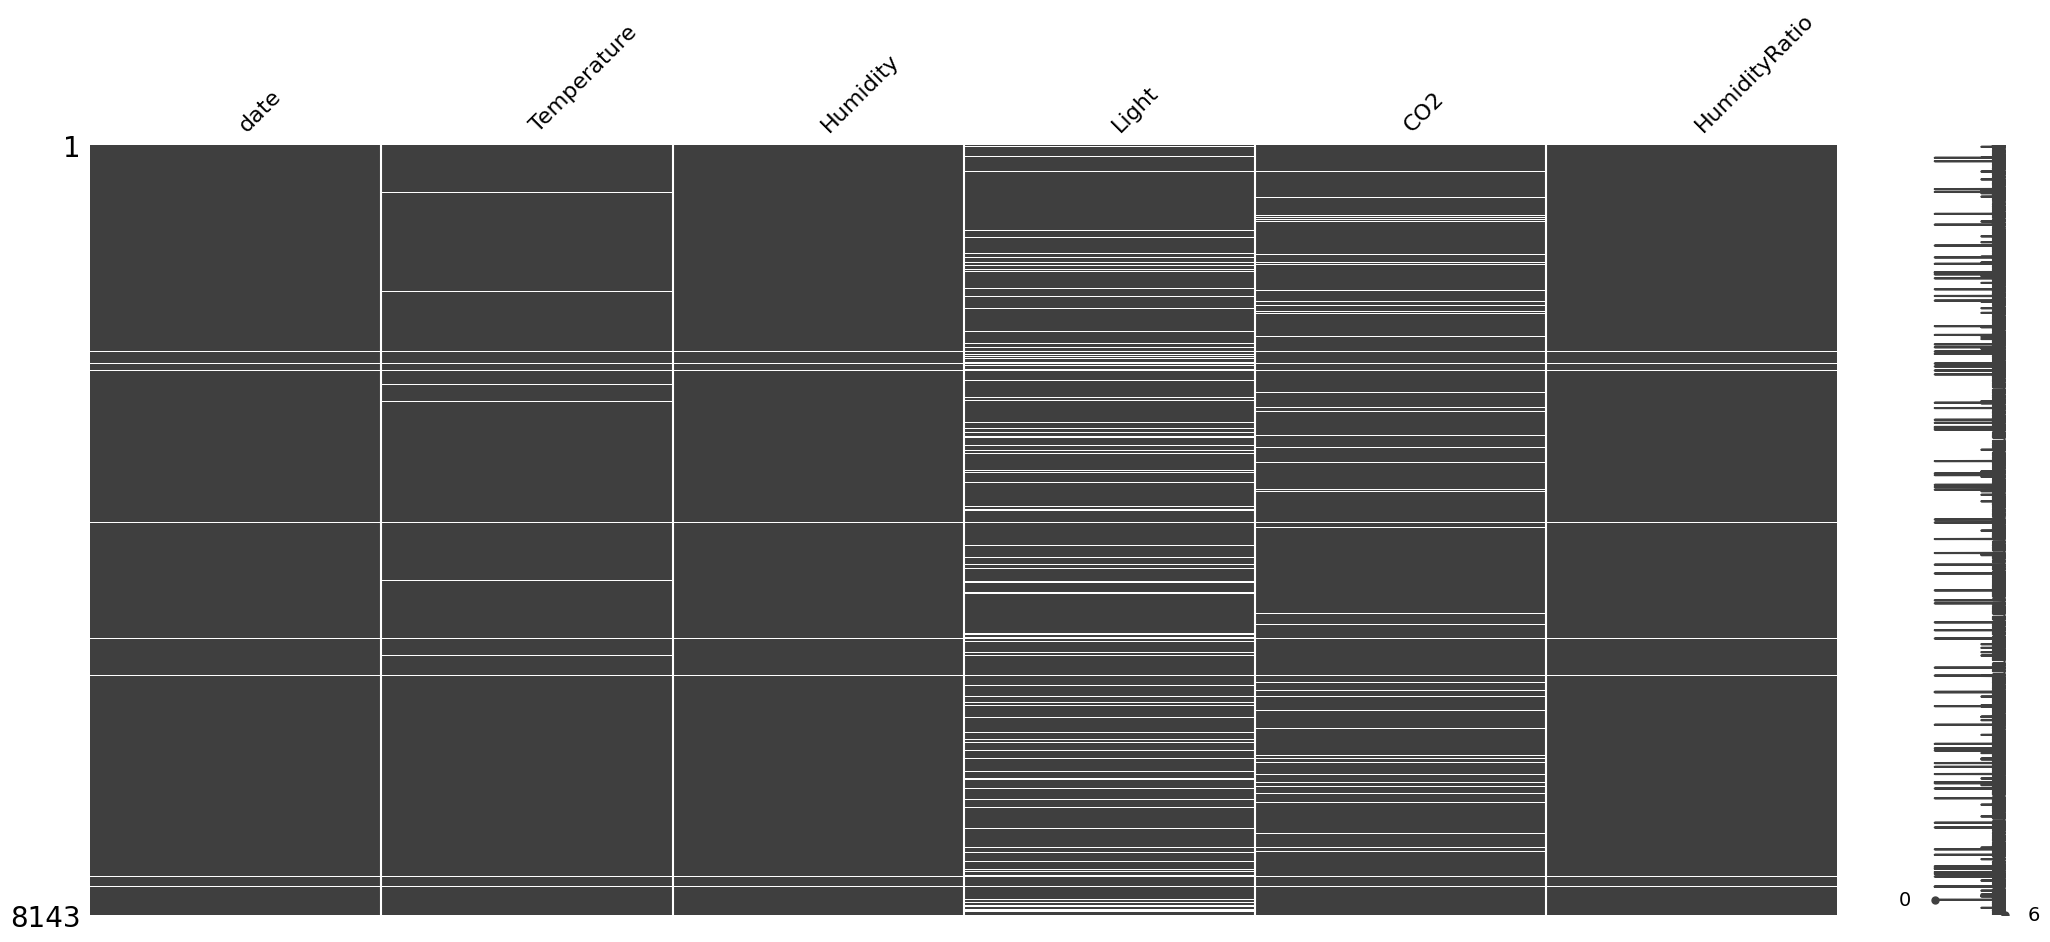

In [101]:
# using the missingno library via the matrix method we can plot where the missing values are located in the feature matrix
msno.matrix(X)

Since the missing values are very little I only will use imputation method to fill the gaps.

# Data Transformation Pipeline

Here, I defined the data transformation pipelines.

For the numerical sensor features (**Temperature, Humidity, Light, CO2, and HumidityRatio**) the pipeline is composed of two primary transformers:


*   KNNImputer: As we have intentionally introduced missing values to simulate real-world hardware failures, we apply an imputation strategy. The `KNNImputer` estimates these missing values by finding the k-nearest neighbors in the feature space.
*   StandardScaler: The features represent different physical units and scales. We apply standardization to ensure all features have a mean of 0 and a standard deviation of 1.


For the **date** feature first let's see if there is any relation between occupancy and the hour of the day.

In [102]:
hours_1 = []
hours_0 = []
for date in df[df['Occupancy'] == 1]['date']:
    hours_1.append(date.hour)
for date in df[df['Occupancy'] == 0]['date']:
    hours_0.append(date.hour)

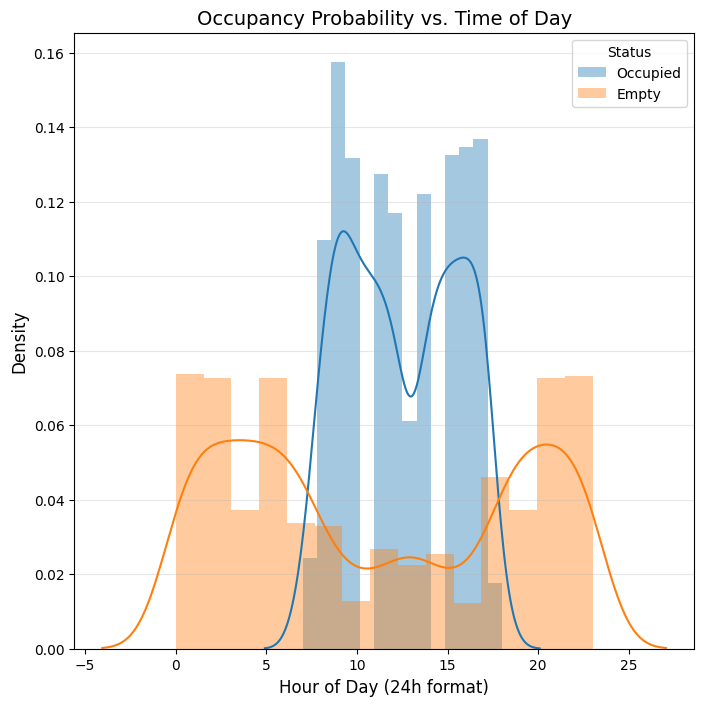

In [103]:
plt.figure(figsize=(8,8))
ax = sns.distplot(hours_1, label='Occupied')
ax = sns.distplot(hours_0, label='Empty')
plt.title('Occupancy Probability vs. Time of Day', fontsize=14)
plt.xlabel('Hour of Day (24h format)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Status')
plt.grid(axis='y', alpha=0.3)

plt.show()

From the above graph, we can see that between 07:00 and 18:00 there are occupants in the environment. But during non-working hours, we can  say that there are no occupants.

With this information, we can implement a Custom Transformer (`WorkingHourTransformer`) to derive a new binary feature from the date column (1 for working hours between 07:00 and 18:00, and 0 otherwise.)

In [104]:
class WorkingHourTransformer(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self
  def transform(self, X):
    X_df = pd.DataFrame(X)
    date_series = pd.to_datetime(X_df.iloc[:, 0])

    working_hours = date_series.dt.hour.apply(lambda x: 1 if (x >= 7 and x<= 17) else 0)
    return working_hours.values.reshape(-1, 1)


In [105]:
# Here are the definitions of Pipelines and ColumnTransformer

sensor_features = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']

pipeline1 = Pipeline([
    ('imp', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

final_transformation = ColumnTransformer(transformers=[
   ('num_sensors', pipeline1, sensor_features),
   ('working_hour', WorkingHourTransformer(), ['date'])
],
remainder='drop',
verbose_feature_names_out=False
)

# Training and Test Sets

In [106]:
# splitting the entire dataset into training and test sets, 20% of the instances in the test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42, shuffle=True)

# Model Selection

In this section we will identify the most effective model from our candidate models (**Logistic Rgression, K-Nearest Neighbors,  Perceptron and Random Forest**) through the nested-cross validation process which allows us to optimize hyperparameters and assess model stability simultaneously. We will also test whether auxiliary techniques such as **SMOTE** for class imbalance or **PCA** for dimensionality reduction enhance the predictive performance of our system.

Before running the Nested Cross-Validation, let's check our preprocessing pipeline is functioning correctly using a baseline Logistic Regression model.

In [107]:
model_pipeline = IMBPipeline([
    ('transformation', final_transformation),
    ('sampler', SMOTE(random_state=42)),
    ('dim_red', PCA(n_components=0.8)),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [108]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('transformation',
                 ColumnTransformer(transformers=[('num_sensors',
                                                  Pipeline(steps=[('imp',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Temperature', 'Humidity',
                                                   'Light', 'CO2',
                                                   'HumidityRatio']),
                                                 ('working_hour',
                                                  WorkingHourTransformer(),
                                                  ['date'])],
                                   verbose_feature_names_out=False)),
                ('sampler', SMOTE(random_state=42)),
                ('dim_red', PCA(n_components=0.8)),
                ('classifier', LogisticRegression(max_iter=1000))])

In [109]:
sampler_configs = [
    {'sampler': [None]},
    {
      'sampler': [SMOTE()],
      'sampler__sampling_strategy': ['minority', 1.2, 0.9, 0.7]
    },
    {
        'sampler': [RandomOverSampler()],
        'sampler__sampling_strategy': ['minority', 1.2, 0.9, 0.7]
    }
]

dim_reduction_configs = [
    {'dim_red': [None]},
    {
        'dim_red': [PCA()],
        'dim_red__n_components': [0.5, 0.7, 0.9]
    },
    {'dim_red': [LDA()]},
    {
        'dim_red': [SFS(estimator=Perceptron(), cv=None, scoring='f1')],
        'dim_red__estimator': [Perceptron(), LogisticRegression()],
        'dim_red__n_features_to_select' : [3, 4, 5]
    }
]

classifier_configs = [
    {
        'classifier': [Perceptron()],
        'classifier__eta0' : loguniform(0.001, 100),
        'classifier__max_iter': [1, 5, 10, 15, 50, 100],
        'classifier__class_weight' : [None, 'balanced']
    },
    {
        'classifier': [LogisticRegression(solver='saga', max_iter=2000)],
        'classifier__C' : loguniform(0.001, 100),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__class_weight' : [None, 'balanced']
    },
    {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [3, 5, 7, 9]
    },
    {
        'classifier' : [RandomForestClassifier()],
        'classifier__n_estimators' : [10, 50, 100, 500]
    }
]

To perform an exhaustive search, we must combine our individual component configurations into a single list of dictionaries that `RandomizedSearchCV` can interpret. We use itertools.product to calculate the Cartesian product of the samplers, dimensionality reducers, and classifiers.

In [110]:
all_configs = []

for configuration in itertools.product(sampler_configs, dim_reduction_configs, classifier_configs):
    all_parameters = []
    for element in configuration:
        for item in element.items():
            all_parameters.append(item)

    all_configs.append(dict(all_parameters))

print(f"Total {len(all_configs)} possible pipeline configurations.")

Total 48 possible pipeline configurations.


In [111]:
all_configs[0]

{'sampler': [None],
 'dim_red': [None],
 'classifier': [Perceptron()],
 'classifier__eta0': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x78c172bf1250>,
 'classifier__max_iter': [1, 5, 10, 15, 50, 100],
 'classifier__class_weight': [None, 'balanced']}

Now let's use RandomizedSearchCV to navigate our search space efficiently. By sampling 50 random combinations from our all_configs list, we identify the best-performing pipeline structure and hyperparameters.

In [112]:
inner_cv = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=all_configs,
    n_iter=50,
    cv=2,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

Now we implement the Outer Loop using the `cross_validate` function. It provides a robust estimate of our model's performance by evaluating the entire optimization process across 5 different folds. By setting `return_estimator = True`, we preserve the best-tuned model from each fold for further analysis.

In [113]:
scores = cross_validate(
    inner_cv,
    X_train,
    y_train,
    cv=5,
    scoring='f1',
    return_estimator=True,
    verbose=3
)

[CV] END ......................................., score=0.962 total time= 1.0min
[CV] END ......................................., score=0.969 total time= 1.0min
[CV] END ......................................., score=0.980 total time=  52.6s
[CV] END ......................................., score=0.953 total time= 1.2min
[CV] END ......................................., score=0.968 total time=  53.6s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  5.0min finished


To get the overview of the performances of the best models, let's check the model pipeline and the final score

In [114]:
for index, estimator in enumerate(scores['estimator']):
  print(estimator.best_estimator_.get_params()['sampler'])
  print(estimator.best_estimator_.get_params()['dim_red'])
  print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
  print(scores['test_score'][index])
  print('-'*10)

None
None
RandomForestClassifier(n_estimators=50) {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
0.9616087751371115
----------
None
None
RandomForestClassifier(n_estimators=50) {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
0.9690346083788707
----------
None
None


Evaluating their performance on the test set:

In [115]:
for estimator in scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.9949127906976745, F1 on test set:0.9797687861271677
F1 on training set:0.9949127906976745, F1 on test set:0.9798270893371758
F1 on training set:0.995277878677806, F1 on test set:0.9784172661870504
F1 on training set:0.995277878677806, F1 on test set:0.9742120343839542
F1 on training set:0.995277878677806, F1 on test set:0.9784172661870504


# Refinement of the Selected Model


Following the results of the nested cross-validation, we have identified the Random Forest Classifier as the optimal architecture for this dataset. In this refinement stage, we fix the pipeline to this specific modeling approach and perform a targeted hyperparameter search.

In [117]:
best_model_pipeline = IMBPipeline([
    ('transformation', final_transformation),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [118]:
params = {
    'classifier__n_estimators': [ 100, 125, 150],
    'classifier__max_depth': [5, 8, 12],
    'classifier__min_samples_leaf': [5, 10]
}

In [119]:
rs_best = RandomizedSearchCV(
    estimator = best_model_pipeline,
    param_distributions = params,
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42),
    n_iter = 18,
    scoring = 'f1',
    n_jobs = -1,
    verbose = 1
)

In [120]:
rs_best.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


RandomizedSearchCV(cv=RepeatedStratifiedKFold(n_repeats=1, n_splits=5, random_state=42),
                   estimator=Pipeline(steps=[('transformation',
                                              ColumnTransformer(transformers=[('num_sensors',
                                                                               Pipeline(steps=[('imp',
                                                                                                KNNImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Temperature',
                                                                                'Humidity',
                                                                                'Light',
                                                                                'CO2',
                                                                                'HumidityRatio']),
                                                                              ('working_hour',
                                                                               WorkingHourTransformer(),
                                                                               ['date'])],
                                                                verbose_feature_names_out=False)),
                                             ('classifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=18, n_jobs=-1,
                   param_distributions={'classifier__max_depth': [5, 8, 12],
                                        'classifier__min_samples_leaf': [5, 10],
                                        'classifier__n_estimators': [100, 125,
                                                                     150]},
                   scoring='f1', verbose=1)

In [121]:
rs_best.best_params_

{'classifier__n_estimators': 100,
 'classifier__min_samples_leaf': 5,
 'classifier__max_depth': 12}

# Final Evaluation on Test Set

Final Performance on Unseen Test Data: 
--------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1283
           1       0.97      0.98      0.98       346

    accuracy                           0.99      1629
   macro avg       0.98      0.99      0.98      1629
weighted avg       0.99      0.99      0.99      1629


 Confusion Matrix:


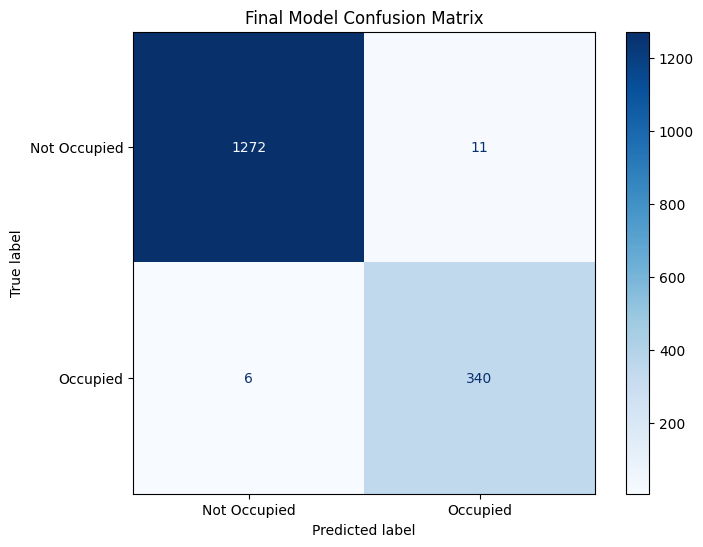

In [122]:
y_pred = rs_best.predict(X_test)
print("Final Performance on Unseen Test Data: ")
print("-"*50)
print(classification_report(y_test, y_pred))
print("\n Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Occupied', 'Occupied'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Final Model Confusion Matrix')
plt.show()


In [123]:
print(f'Final model f1 score {f1_score(y_test, y_pred)}')

Final model f1 score 0.975609756097561


# Model Diagnostic: Learning and Validation Curves
we can evaluate the model’s behavior using learning and validation curves. These diagnostics are essential to determine if the model is suffering from High Variance (overfitting) or High Bias (underfitting). By visualizing the gap between training and validation scores, we can verify that our regularization efforts successfully produced a model that generalizes well to unseen data.

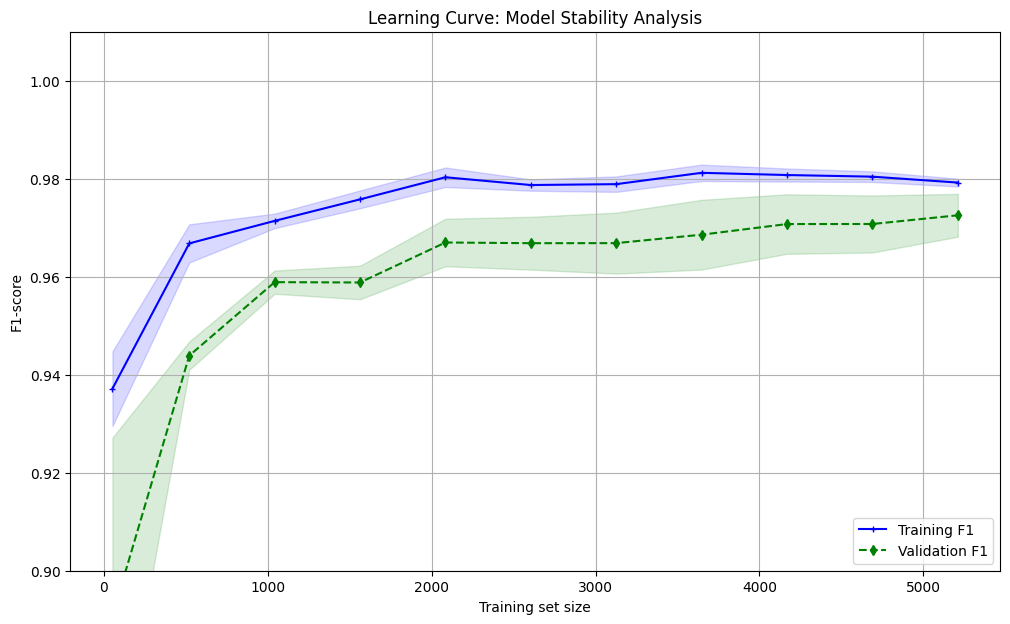

In [124]:
cls = rs_best.best_estimator_

train_sizes, train_scores, test_scores = learning_curve(
    cls,
    X=X_train,
    y=y_train,
    train_sizes=[0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    cv=5,
    n_jobs=-1,
    scoring='f1',
    shuffle=False
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot()

ax.plot(train_sizes, train_mean, color='blue', marker='+', markersize=5, label='Training F1')
ax.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean, color='green', linestyle='--', marker='d', markersize=5, label='Validation F1')
ax.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Training set size')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')
ax.set_ylim([0.90, 1.01])
plt.title("Learning Curve: Model Stability Analysis")
plt.show()

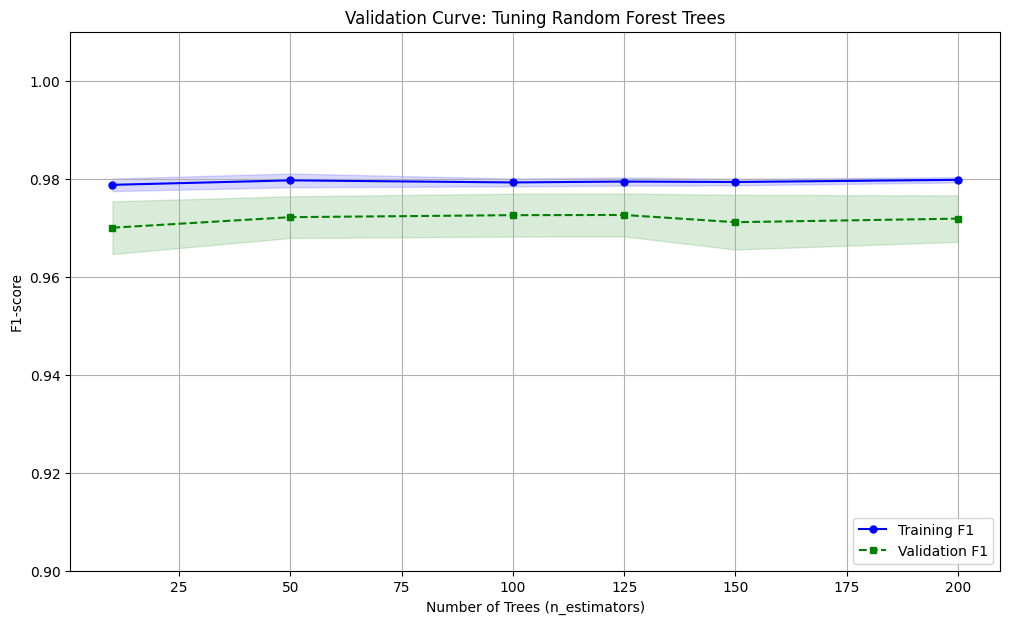

In [125]:
range_estimators = [10, 50, 100, 125, 150, 200]

train_scores, test_scores = validation_curve(
    cls,
    X=X_train,
    y=y_train,
    param_range=range_estimators,
    param_name='classifier__n_estimators',
    cv=5,
    n_jobs=-1,
    scoring='f1'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot()

ax.plot(range_estimators, train_mean, color='blue', marker='o', markersize=5, label='Training F1')
ax.fill_between(range_estimators, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

ax.plot(range_estimators, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation F1')
ax.fill_between(range_estimators, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Number of Trees (n_estimators)')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')
ax.set_ylim([0.90, 1.01])
plt.title("Validation Curve: Tuning Random Forest Trees")
plt.show()